In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sanan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
df = pd.read_csv('emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


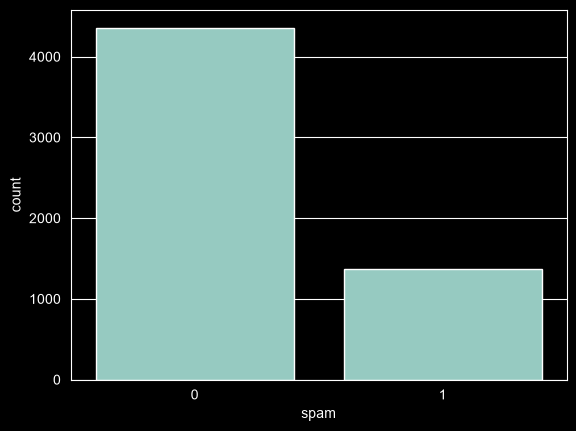

In [15]:
sns.countplot(x=df['spam'], data=df)
plt.show()


In [16]:
spam_msg = df[df['spam'] == 1]
norm_msg =  df[df['spam'] == 0]

norm_msg_balanced = norm_msg.sample(n=len(spam_msg), random_state=42)

balanced_data = pd.concat([spam_msg, norm_msg_balanced]).reset_index(drop=True)
balanced_data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


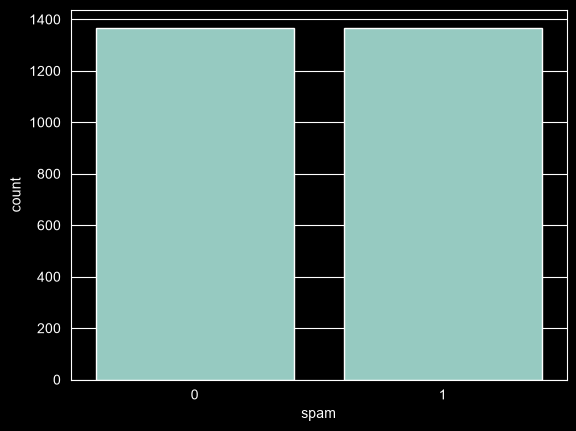

In [17]:
sns.countplot(x=balanced_data['spam'], data=balanced_data)
plt.show()

In [18]:
stop_words = set(stopwords.words('english'))

def remove_text(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    filtered_words = []
    for word in words:
        if word.lower() not in stop_words:
            filtered_words.append(word)

    return "".join(filtered_words)

In [19]:
balanced_data['spam'] = balanced_data['spam'].apply(remove_text)

balanced_data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,
1,Subject: the stock trading gunslinger fanny i...,
2,Subject: unbelievable new homes made easy im ...,
3,Subject: 4 color printing special request add...,
4,"Subject: do not have money , get software cds ...",


In [20]:
y = balanced_data['spam']
X = balanced_data.drop('spam', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)